# 멋진 챗봇 만들기

In [500]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from konlpy.tag import Mecab
from gensim.models import KeyedVectors

import random
from tqdm import tqdm
import sentencepiece as spm
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import itertools

import os

In [501]:
CFG = {
    "PRE_MAX_LEN": 50,
    "DEVICE": (lambda: torch.device("cuda") if torch.cuda.is_available() 
        else torch.device("mps") if torch.backends.mps.is_available() 
        else torch.device("cpu")
    )(),
    "VOCAB_SIZE": 2811,
    "AUG_DATA": "data/ko.kv",
    "TRAIN_SIZE": 0.8,
    "VAL_SIZE": 0.15,
    "TEST_SIZE": 0.05,

    "DROPOUT": 0.5,
    "D_MODEL": 512,
    "D_FF": 1024,
    'N_LAYER': 2,

    "BATCH_SIZE": 64,
    "EPOCHS": 12,
    "WARMUP_STEPS": 600,
    "LABEL_SMOOTHING": 0.1,
    "WEIGHT_DECAY": 1e-4,

    "GRID_SEARCH": True
}

if(CFG["DEVICE"].type == "mps"):
    MOCAB_PATH = "/opt/homebrew/lib/mecab/dic/mecab-ko-dic"
    os.environ["MECABRC"] = MOCAB_PATH
    mecab = Mecab(MOCAB_PATH)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
else:
    mecab = Mecab()

In [502]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table


In [503]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights


In [504]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

In [505]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

In [506]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn


In [507]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)


In [508]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns


In [509]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns


In [510]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=CFG["N_LAYER"],
    d_model=CFG["D_MODEL"],
    n_heads=8,
    d_ff=CFG["D_FF"],
    src_vocab_size=CFG["VOCAB_SIZE"],
    tgt_vocab_size=CFG["VOCAB_SIZE"],
    pos_len=200,
    dropout=CFG["DROPOUT"],
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(CFG["DEVICE"])

#d_model = CFG["D_MODEL"]


In [511]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


In [512]:
def loss_function(real, pred, label_smoothing=None):
    """
    real: [batch_size, seq_len] 
    pred: [batch_size, seq_len, num_classes] 
    """
    real = real.to(CFG["DEVICE"])
    pred = pred.to(CFG["DEVICE"])

    # 예측 텐서 [B*seq_len, num_classes] 로 변환
    pred = pred.view(-1, pred.size(-1))
    # 정답 텐서 [B*seq_len] 로 변환
    real = real.contiguous().view(-1)

    # 📌 수정된 로직: label_smoothing=0.1 추가
    # ignore_index=0: 패딩 토큰(0)은 무시
    # label_smoothing=0.1: 모델의 과잉 확신을 방지하여 과적합 억제
    loss = F.cross_entropy(pred, real, ignore_index=0, label_smoothing=label_smoothing if label_smoothing is not None else CFG["LABEL_SMOOTHING"])
    
    return loss


# Data 준비

## Step 1. 데이터 다운로드

In [513]:
import numpy 
import pandas as pd
import torch
import nltk
import gensim
import re

print(numpy.__version__)
print(pd.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.4.2
3.0.0
2.10.0
3.9.2
4.4.0


### Data 다운로드

In [514]:
url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
df = pd.read_csv(url)
print(df.head())

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


### questions, answers 변수에 나눠서 저장

In [515]:
questions = df['Q'].tolist()
answers   = df['A'].tolist()

print(questions[0])
print(answers[0])

12시 땡!
하루가 또 가네요.


## Step 2. 데이터 정제
### preprocess_sentence() 함수를 구현하세요.
- 영문자의 경우, 모두 소문자로 변환합니다.
- 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거합니다.

In [516]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence) # 영어,숫자,한글,특수무자 제외하고 제거
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    
    return sentence

In [517]:
after_prepro_questions = list(map(preprocess_sentence, questions))

print(questions[:10])
print(after_prepro_questions[:10])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네', 'SD카드 망가졌어', 'SD카드 안돼', 'SNS 맞팔 왜 안하지ㅠㅠ', 'SNS 시간낭비인 거 아는데 매일 하는 중', 'SNS 시간낭비인데 자꾸 보게됨']
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'ppl 심하네', 'sd카드 망가졌어', 'sd카드 안돼', 'sns 맞팔 왜 안하지ㅠㅠ', 'sns 시간낭비인 거 아는데 매일 하는 중', 'sns 시간낭비인데 자꾸 보게됨']


## Test data 분리

## Step 3. 데이터 토큰화((`build_corpus`)
이 섹션에서는 한국어 형태소 분석기인 **Mecab**을 사용하여 데이터를 토큰화하고, 학습에 적합한 형태로 정제하여 최종 코퍼스를 구축합니다.
### 1. 토크나이저 설정 (Mecab)
* **환경별 최적화**: Apple Silicon(MPS) 환경인 경우 사전 경로를 직접 지정하고, 그 외의 경우 기본 설정을 사용하여 `mecab` 인스턴스를 생성합니다.
### 2. 코퍼스 구축 함수 (`build_corpus`) 구현
입력받은 질문(`src_data`)과 답변(`tgt_data`) 데이터에 대해 다음 과정을 거칩니다:
1. **정제**: `preprocess_sentence`를 통해 문장을 깨끗하게 만듭니다.
2. **토큰화**: 전달받은 `tokenize_func`(Mecab)을 사용하여 형태소 분석을 수행합니다.
3. **길이 제한**: 토큰 개수가 `max_len`(50) 이하인 문장 쌍만 선택합니다.
4. **중복 제거**: 질문과 답변을 각각 독립적으로 체크하여 중복된 문장이 포함된 쌍을 제거합니다.
#### 3. 최종 데이터 생성
* 구현된 함수를 실행하여 `que_corpus`와 `ans_corpus`를 생성하고, 최종 데이터의 개수와 토큰화 예시를 출력하여 확인합니다.

In [518]:

def build_corpus(src_data, tgt_data, tokenize_func, max_len=50):
    que_corpus = []
    ans_corpus = []
    
    seen_src = set()
    seen_tgt = set()
    for src, tgt in zip(src_data, tgt_data):
        # 1) preprocess_sentence() 함수로 정제
        pre_src = preprocess_sentence(src)
        pre_tgt = preprocess_sentence(tgt)
        
        # 2) 전달받은 토크나이즈 함수(mecab.morphs)로 토큰화
        src_tokens = tokenize_func(pre_src)
        tgt_tokens = tokenize_func(pre_tgt)
        
        # 3) 길이 제한 확인
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            # 4) 중복 제거 (소는 소스대로, 타겟은 타겟대로 독립 검사)
            # 쌍의 관계를 유지하기 위해 한쪽이라도 중복이면 해당 쌍 전체를 제외합니다.
            if pre_src not in seen_src and pre_tgt not in seen_tgt:
                seen_src.add(pre_src)
                seen_tgt.add(pre_tgt)
                
                que_corpus.append(src_tokens)
                ans_corpus.append(tgt_tokens)
                
    return que_corpus, ans_corpus

In [519]:
# 전체 데이터(questions, answers)에 대해 먼저 수행
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_len=CFG["PRE_MAX_LEN"])

print(f"최종 정제된 코퍼스 크기: {len(que_corpus)}")

최종 정제된 코퍼스 크기: 7739


## Step 4. Train / Test 데이터 분리
정제가 끝난 형태소 코퍼스를 분리합니다.

In [520]:
# CFG의 비율을 계산에 활용
# 1단계: Train vs (Val + Test)
rem_size = CFG["VAL_SIZE"] + CFG["TEST_SIZE"]
que_train, que_rem, ans_train, ans_rem = train_test_split(
    que_corpus,
    ans_corpus,
    test_size=rem_size,
    shuffle=True,
    random_state=42,
)

# 2단계: 남은 데이터를 다시 Val과 Test로 분리
# (전체 대비 비율을 rem_size 내의 비율로 환산)
val_ratio = CFG["VAL_SIZE"] / rem_size 
que_val, que_test, ans_val, ans_test = train_test_split(
    que_rem,
    ans_rem,
    test_size=(1 - val_ratio), # 남는 부분이 Test_size가 됨
    shuffle=True,
    random_state=42,
)

print(f"[Configuration Split Result]")
print(f"- Train      : {len(que_train)} ({CFG["TRAIN_SIZE"]*100}%)")
print(f"- Validation : {len(que_val)} ({CFG["VAL_SIZE"]*100}%)")
print(f"- Test       : {len(que_test)} ({CFG["TEST_SIZE"]*100}%)")

[Configuration Split Result]
- Train      : 6191 (80.0%)
- Validation : 1160 (15.0%)
- Test       : 388 (5.0%)


In [521]:
print(que_train[:10])

[['결혼', '이나', '하', '지', '왜', '자꾸', '나', '한테', '화', '내', '냐구', '!'], ['잘', '지내', '고', '있', '는지', '궁금', '해', '지네'], ['복근', '만들', '어야지'], ['양가', '부모', '가', '원', '하', '지', '않', '는다면'], ['너무', '나', '와', '닿', '는', '그런', '표현', '이', '아닐까', '하', '네'], ['신입', '이', '벌써', '치', '고', '올라온다'], ['이', '어', '주', '려고', '해서', '더', '어색', '해졌', '어'], ['어떻게', '해야', '오래', '만날', '수', '있', '을까', '?'], ['꿈', '이', '없', '어'], ['오늘', '연락', '왔', '어']]


## ## Step 4. 데이터 증강 (Augmentation)

주어진 약 1만 개의 데이터를 기반으로 **Lexical Substitution(어휘 치환)** 기술을 적용하여 데이터를 증강합니다. 이를 위해 한국어 사전 훈련된 Embedding 모델(`ko.bin`)을 활용하며, 전체 데이터가 원본 대비 **3배**가 되도록 구성하는 요구사항을 이행합니다.

### ✅ 요구사항 이행 내용
*   **사전 훈련 모델 활용**: `Kyubyong/wordvectors`의 Korean(w) 모델을 사용하여 문맥적으로 유사한 단어로 치환합니다.
*   **3배 증강 전략 적용**:
    1. **1배수**: `Augmented Questions` + `Original Answers` (질문만 변형)
    2. **2배수**: `Original Questions` + `Augmented Answers` (답변만 변형)
    3. **3배수**: `Original Questions` + `Original Answers` (원본 유지)
    * 결과적으로 약 7,700개의 원본 데이터를 **약 23,000개**의 풍부한 코퍼스로 확장하였습니다.

---

### 🛠️ 기술적 해결 과정: `ko.bin`에서 `ko.kv`로의 변환
다운로드한 `ko.bin` 파일이 최신 파이썬(3.12) 및 Gensim(4.4.0) 환경과 호환되지 않는 문제(AttributeError)를 다음과 같이 해결하였습니다.

1.  **문제 파악**: `ko.bin`은 구버전 파이썬의 **Pickle** 방식으로 저장되어 최신 라이브러리 구조와 충돌이 발생했습니다.
2.  **원본 데이터 활용**: 압축 파일에 함께 포함된 텍스트 형식의 **[ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)** 파일(단어와 벡터값이 명시된 원본)을 확보했습니다.
3.  **변환 로직 수행**:
    *   [ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)를 파싱하여 30,185개의 단어와 각 200차원의 숫자 벡터를 추출했습니다.
    *   현대적이고 효율적인 바이너리 저장 방식인 **KeyedVectors** 객체로 재조립했습니다.
4.  **최적화 결과 (`ko.kv`)**: 
    *   **호환성**: 현재 환경에서 직접 생성하여 오류 없이 즉시 로드됩니다.
    *   **경량화**: 불필요한 메타데이터를 제거하여 용량을 약 **25MB**로 최적화했습니다.
    *   **성능**: `load()` 속도가 0.1초 내외로 매우 빠르며 `most_similar()` 기능을 완벽히 지원합니다.

이제 이 고성능 `ko.kv` 모델을 사용하여 안정적으로 증강 작업을 진행할 수 있습니다.


In [522]:
word2vec = KeyedVectors.load(CFG["AUG_DATA"])
# 테스트
print("테스트 유사어:", word2vec.most_similar("사랑", topn=3))

테스트 유사어: [('슬픔', 0.7216663360595703), ('행복', 0.6759077906608582), ('절망', 0.6468985080718994)]


In [523]:
def lexical_sub(sentence, word2vec):
    """
    이미 토큰화된 리스트(sentence)를 입력받아
    Word2Vec 사전에 존재하는 단어만 후보로 삼아 유사어로 교체합니다.
    """
    res = []
    toks = sentence

    try:
        # 📌 핵심 수정: Word2Vec 사전에 존재하는 단어(=교체 가능한 단어)만 추려냅니다.
        valid_tokens = [tok for tok in toks if tok in word2vec.key_to_index]
        
        # 바꿀 수 있는 단어가 아예 없으면 원본 그대로 반환
        if not valid_tokens:
            return toks
            
        # 의미 있는 단어 중에서 랜덤 선택
        _from = random.choice(valid_tokens)
        
        # 유사어 추출 (너무 엉뚱한 단어가 안 나오게 TOP 5로 줄임)
        candidates = word2vec.most_similar(_from, topn=5)
        _to = random.choice(candidates)[0]
        
        # 선택된 단어 치환
        res = [tok if tok != _from else _to for tok in toks]
    except Exception as e:
        # 예측 불가능한 에러 발생 시 원본 반환
        res = toks

    return res

print("lexical_sub 함수 정의 완료 (수정본: 사전 기반 안전 추출)")


lexical_sub 함수 정의 완료 (수정본: 사전 기반 안전 추출)


In [524]:
added_que_corpus = []
added_ans_corpus = []
original_len = len(que_train)

print("1단계 증강 중: Augmented Q + Original A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(lexical_sub(que_train[i], word2vec))
    added_ans_corpus.append(ans_train[i])

print("2단계 증강 중: Original Q + Augmented A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(que_train[i])
    added_ans_corpus.append(lexical_sub(ans_train[i], word2vec))

que_train += added_que_corpus
ans_train += added_ans_corpus

print(f"✅ 증강 완료! 최종 Train 코퍼스 크기: {len(que_train)}")

1단계 증강 중: Augmented Q + Original A...


100%|██████████| 6191/6191 [00:02<00:00, 3034.72it/s]


2단계 증강 중: Original Q + Augmented A...


100%|██████████| 6191/6191 [00:01<00:00, 3458.24it/s]

✅ 증강 완료! 최종 Train 코퍼스 크기: 18573


## Step 5. 데이터 벡터화

In [525]:
def generate_tokenizer(corpus, vocab_size, lang="kor", pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    file = f"./{lang}_corpus.txt"
    model = f"{lang}_spm"
    with open(file, 'w', encoding='utf-8') as f:
        for row in corpus: f.write(" ".join(row) + '\n')
    

    # 명령어 인자 사이에 공백(' ')이 확실히 들어가도록 수정
    # spa_spm.model: 퓨터만 읽을 수 있는 이진(Binary) 형태의 핵심 사전(모델) 파일입니다
    # spa_spm.vocab:  사람이 직접 눈으로 열어서 볼 수 있는 단순한 '어휘 텍스트 목록' 파일입니다.
    # 기본 Unigram
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size} '
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')
    return tokenizer


In [526]:
# Tokenizer는 Train 데이터만 보고 학습합니다.
tokenizer = generate_tokenizer(que_train + ans_train, CFG["VOCAB_SIZE"], "kor")
tokenizer.set_encode_extra_options("bos:eos")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./kor_corpus.txt --model_prefix=kor_spm --vocab_size=2811 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./kor_corpus.txt
  input_format: 
  model_prefix: kor_spm
  model_type: UNIGRAM
  vocab_size: 2811
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3

True

In [527]:
def make_corpus(sentences, tokenizer):
    corpus = []
    # [['인간', '의', '성향', '은', '변하', '지', '않', '나', '봅니다', '.'], ['첫', '사랑', '을', '다시', '만났', '어', '.'], ['좋', '아', '하', '는', '여자', '애', '가', '남친', '사귈', '마음', '이', '없', '다는', '데', '진짜', '일까', '?']
    for sentence in tqdm(sentences):
        sentence_str = " ".join(sentence)  
        tokens = tokenizer.encode_as_ids(sentence_str)
        corpus.append(tokens)
    return corpus


In [528]:
enc_train = make_corpus(que_train, tokenizer)
dec_train = make_corpus(ans_train, tokenizer)

enc_val = make_corpus(que_val, tokenizer)
dec_val = make_corpus(ans_val, tokenizer)

enc_test = make_corpus(que_test, tokenizer)
dec_test = make_corpus(ans_test, tokenizer)

100%|██████████| 388/388 [00:00<00:00, 267794.96it/s]


In [529]:
# for test
i = 0  # 보고 싶은 인덱스
# que_corpus -> que_train으로 변경
print("SRC original:", que_train[i])
print("SRC ids     :", enc_train[i])
# 이제 올바른 1차원 시퀀스이므로 정상 동작합니다.
src_pieces = [tokenizer.id_to_piece(tid) for tid in enc_train[i]]
print("SRC pieces  :", src_pieces)
print("SRC decoded :", tokenizer.decode_ids(enc_train[i]))
print("\n==== Decoder sample ====")

# ans_corpus -> ans_train으로 변경
print("TGT original:", ans_train[i])
print("TGT ids     :", dec_train[i])
# 올바른 1차원 시퀀스
tgt_pieces = [tokenizer.id_to_piece(tid) for tid in dec_train[i]]
print("TGT pieces  :", tgt_pieces)
print("TGT decoded :", tokenizer.decode_ids(dec_train[i]))

SRC original: ['결혼', '이나', '하', '지', '왜', '자꾸', '나', '한테', '화', '내', '냐구', '!']
SRC ids     : [1, 178, 751, 8, 19, 180, 309, 21, 108, 498, 59, 2425, 144, 2]
SRC pieces  : ['<s>', '▁결혼', '▁이나', '▁하', '▁지', '▁왜', '▁자꾸', '▁나', '▁한테', '▁화', '▁내', '▁냐구', '▁!', '</s>']
SRC decoded : 결혼 이나 하 지 왜 자꾸 나 한테 화 내 냐구 !

==== Decoder sample ====
TGT original: ['힘들', '겠', '네요', '.']
TGT ids     : [1, 74, 70, 28, 48, 4, 2]
TGT pieces  : ['<s>', '▁힘', '들', '▁겠', '▁네요', '▁.', '</s>']
TGT decoded : 힘들 겠 네요 .


In [530]:
def pad_sequences_custom(sequences, max_len=50, pad_value=0, bos_id=1, eos_id=2):
    padded_sequences = []

    for seq in sequences:
        # 텐서라면 리스트로 변환 (중복 실행 방지)
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
            
        # ⭐️ 핵심 방어 로직: 뒤쪽의 패딩(0) 찌꺼기들부터 말끔히 걷어냄
        while len(seq) > 0 and seq[-1] == pad_value:
            seq = seq[:-1]
            
        # 이미 bos/eos가 포함되어 있다면 제거 (명시적으로 처음부터 통제하기 위함)
        if len(seq) > 0 and seq[0] == bos_id:
             seq = seq[1:]
        if len(seq) > 0 and seq[-1] == eos_id:
             seq = seq[:-1]

        # max_len을 맞추기 위해 실제 단어가 들어갈 수 있는 공간은 (max_len - 2)
        max_word_len = max_len - 2 
        
        # 초과 길이는 자르기
        if len(seq) > max_word_len:
            seq = seq[:max_word_len]
            
        # [BOS] + 유효시퀀스 + [EOS] 조립
        seq = [bos_id] + seq + [eos_id]

        # 남은 길이는 pad_value로 채우기
        if len(seq) < max_len:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    return torch.tensor(padded_sequences, dtype=torch.long)


In [531]:
# ⭐️ 수정 포인트: que_train -> enc_train / ans_train -> dec_train
enc_train = pad_sequences_custom(enc_train, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
dec_train = pad_sequences_custom(dec_train, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
# (테스트 셋과 검증 셋도 동일하게 처리해 주시면 됩니다!)
enc_val = pad_sequences_custom(enc_val, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
dec_val = pad_sequences_custom(dec_val, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
enc_test = pad_sequences_custom(enc_test, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
dec_test = pad_sequences_custom(dec_test, max_len=CFG["PRE_MAX_LEN"], pad_value=0)


# 1. 차원(Shape) 확인 
# (정상 출력 예시: torch.Size([배치크기, 50]))
print("=== Tensor Shapes ===")
print("enc_train shape:", enc_train.shape)
print("dec_train shape:", dec_train.shape)
print("enc_val shape  :", enc_val.shape)
print("dec_test shape :", dec_test.shape)
# 2. 실제 데이터 확인 (첫 번째 문장 샘플링)
# 리스트 끝부분에 0(패딩)이 여러 개 붙어있는지 눈으로 확인합니다.
print("\n=== Padding Data Check (Index 0) ===")
print("enc_train[0]:", enc_train[0])
print("dec_train[0]:", dec_train[0])
# 3. 데이터 타입 확인 (정상 출력 예시: torch.int64 또는 torch.long)
print("\n=== Data Type Check ===")
print("enc_train dtype:", enc_train.dtype)

=== Tensor Shapes ===
enc_train shape: torch.Size([18573, 50])
dec_train shape: torch.Size([18573, 50])
enc_val shape  : torch.Size([1160, 50])
dec_test shape : torch.Size([388, 50])

=== Padding Data Check (Index 0) ===
enc_train[0]: tensor([   1,  178,  751,    8,   19,  180,  309,   21,  108,  498,   59, 2425,
         144,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])
dec_train[0]: tensor([ 1, 74, 70, 28, 48,  4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

=== Data Type Check ===
enc_train dtype: torch.int64


## Step 6. Dataset 및 DataLoader 구성
완성된 텐서들을 PyTorch의 과 로 묶어 배치(Batch) 단위로 모델에 공급할 준비를 합니다.

In [532]:
from torch.utils.data import TensorDataset, DataLoader


# Train Dataset & DataLoader
train_dataset = TensorDataset(enc_train, dec_train)
train_dataloader = DataLoader(train_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=True)

# Validation Dataset & DataLoader
val_dataset = TensorDataset(enc_val, dec_val)
val_dataloader = DataLoader(val_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=False)

# Test Dataset & DataLoader
test_dataset = TensorDataset(enc_test, dec_test)
test_dataloader = DataLoader(test_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=False)

print(f"총 Train 배치 개수: {len(train_dataloader)}")
print(f"총 Validation 배치 개수: {len(val_dataloader)}")
print(f"총 Test 배치 개수: {len(test_dataloader)}")

총 Train 배치 개수: 291
총 Validation 배치 개수: 19
총 Test 배치 개수: 7


In [533]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(CFG["DEVICE"])
    dec_lookahead_mask = dec_lookahead_mask.to(CFG["DEVICE"])

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask


In [534]:
def calculate_accuracy(real, pred):
    # 예측값 중 가장 높은 확률의 인덱스 [batch, seq_len]
    predictions = torch.argmax(pred, dim=-1)
    
    # 패딩(0)이 아닌 부분만 마스킹
    mask = (real != 0).float()
    
    # 예측값과 실제 정답 비교
    correct = (predictions == real).float()
    
    # 마스크를 적용하여 실제 단어 구간의 정확도만 계산
    accuracy = (correct * mask).sum() / mask.sum()
    return accuracy

In [535]:
def train_step(src, tgt, model, optimizer, label_smoothing=None):
    model.train()
    optimizer.zero_grad()

    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(CFG["DEVICE"])
    tgt_in = tgt_in.to(CFG["DEVICE"])
    gold = gold.to(CFG["DEVICE"])
    enc_mask = enc_mask.to(CFG["DEVICE"])
    dec_enc_mask = dec_enc_mask.to(CFG["DEVICE"])
    dec_mask = dec_mask.to(CFG["DEVICE"])

    # predictions를 받아옵니다.
    predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    
    # Loss 및 Accuracy 계산
    loss = loss_function(gold, predictions, label_smoothing=label_smoothing)
    acc = calculate_accuracy(gold, predictions) # 📌 Accuracy 계산 추가

    loss.backward()
    optimizer.step()

    return loss, acc # 📌 이제 acc도 함께 반환합니다.


In [536]:
def val_step(src, tgt, model, label_smoothing=None):
    model.eval()
    with torch.no_grad():
        tgt_in = tgt[:, :-1]
        gold = tgt[:, 1:]

        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

        src = src.to(CFG["DEVICE"])
        tgt_in = tgt_in.to(CFG["DEVICE"])
        gold = gold.to(CFG["DEVICE"])
        enc_mask = enc_mask.to(CFG["DEVICE"])
        dec_enc_mask = dec_enc_mask.to(CFG["DEVICE"])
        dec_mask = dec_mask.to(CFG["DEVICE"])

        predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(gold, predictions, label_smoothing=label_smoothing)
        acc = calculate_accuracy(gold, predictions) # 📌 Accuracy 계산 추가

    return loss, acc # 📌 이제 acc도 함께 반환합니다.


In [537]:
def init_weights(m):
    # 1. 일반 선형 결합(Linear) 층 초기화
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight) # 자비에 초기화 (번역 모델 국룰!)
        if m.bias is not None:
             nn.init.constant_(m.bias, 0)
             
    # 2. 임베딩(Embedding) 층 초기화
    elif isinstance(m, nn.Embedding):
        nn.init.normal_(m.weight, mean=0, std=0.01)
        if m.padding_idx is not None:
            nn.init.constant_(m.weight[m.padding_idx], 0)
        
    # 3. 순환 신경망(GRU/LSTM) 층 초기화
    elif isinstance(m, (nn.GRU, nn.LSTM)):
        for name, param in m.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'bias' in name:
                nn.init.constant_(param.data, 0)

transformer.apply(init_weights)
print("✨ [Xavier & Normal] 번역 모델 맞춤형 가중치 초기화가 완료되었습니다.")

✨ [Xavier & Normal] 번역 모델 맞춤형 가중치 초기화가 완료되었습니다.


In [538]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(CFG["D_MODEL"], warmup_steps=CFG["WARMUP_STEPS"])

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.AdamW(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9,
                             weight_decay=CFG["WEIGHT_DECAY"]
                            )


In [539]:
%%time

# 1. 히스토리 기록용 (나중에 그래프 그릴 때 사용)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
global_step = 1

for epoch in range(CFG["EPOCHS"]):
    # --- [ TRAIN ] ---
    transformer.train()
    total_train_loss, total_train_acc = 0.0, 0.0
    train_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1} [Train]")

    for batch, (src, tgt) in enumerate(train_dataloader):
        # LR 스케줄러 업데이트
        lr = learning_rate(global_step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
            
        # 📌 수정: train_step에서 loss와 acc를 함께 리턴받음
        loss, acc = train_step(src, tgt, transformer, optimizer)
        
        global_step += 1
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        
        # 실시간 진행 상황(Tqdm)에 수치 표시
        train_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{acc.item():.4f}"})
        train_bar.update(1)
    train_bar.close()

    # --- [ VALIDATION ] ---
    transformer.eval()
    total_val_loss, total_val_acc = 0.0, 0.0
    val_bar = tqdm(total=len(val_dataloader), desc=f"Epoch {epoch+1} [Val]")

    for batch, (src, tgt) in enumerate(val_dataloader):
        # 📌 수정: val_step에서도 loss와 acc를 함께 리턴받음
        v_loss, v_acc = val_step(src, tgt, transformer)
        total_val_loss += v_loss.item()
        total_val_acc += v_acc.item()
        
        val_bar.set_postfix({"Loss": f"{v_loss.item():.4f}", "Acc": f"{v_acc.item():.4f}"})
        val_bar.update(1)
    val_bar.close()

    # --- [ 최종 결과 계산 및 기록 ] ---
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)
    avg_val_loss = total_val_loss / len(val_dataloader)
    avg_val_acc = total_val_acc / len(val_dataloader)
    
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"\n✨ Epoch {epoch+1} Summary")
    print(f"   - Train Loss: {avg_train_loss:.4f}  |  Train Acc: {avg_train_acc:.4f}")
    print(f"   - Val Loss  : {avg_val_loss:.4f}  |  Val Acc  : {avg_val_acc:.4f}")
    print("-" * 60)


Epoch 1 [Val]: 100%|██████████| 19/19 [00:00<00:00, 40.78it/s, Loss=4.8736, Acc=0.3100]



✨ Epoch 1 Summary
   - Train Loss: 6.4686  |  Train Acc: 0.1511
   - Val Loss  : 4.8692  |  Val Acc  : 0.3075
------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 19/19 [00:00<00:00, 41.28it/s, Loss=4.7805, Acc=0.3800]



✨ Epoch 2 Summary
   - Train Loss: 4.7147  |  Train Acc: 0.3205
   - Val Loss  : 4.5059  |  Val Acc  : 0.3762
------------------------------------------------------------


Epoch 3 [Val]: 100%|██████████| 19/19 [00:00<00:00, 41.00it/s, Loss=4.7688, Acc=0.3300]


...


✨ Epoch 10 Summary
   - Train Loss: 3.1925  |  Train Acc: 0.5060
   - Val Loss  : 4.3617  |  Val Acc  : 0.4379
------------------------------------------------------------


Epoch 11 [Val]: 100%|██████████| 19/19 [00:00<00:00, 40.70it/s, Loss=4.5480, Acc=0.4500]



✨ Epoch 11 Summary
   - Train Loss: 3.0934  |  Train Acc: 0.5240
   - Val Loss  : 4.4112  |  Val Acc  : 0.4394
------------------------------------------------------------


Epoch 12 [Val]: 100%|██████████| 19/19 [00:00<00:00, 40.71it/s, Loss=4.7510, Acc=0.3900]


✨ Epoch 12 Summary
   - Train Loss: 2.9963  |  Train Acc: 0.5429
   - Val Loss  : 4.4770  |  Val Acc  : 0.4383
------------------------------------------------------------
CPU times: user 1min 1s, sys: 15.4 s, total: 1min 16s
Wall time: 4min 7s


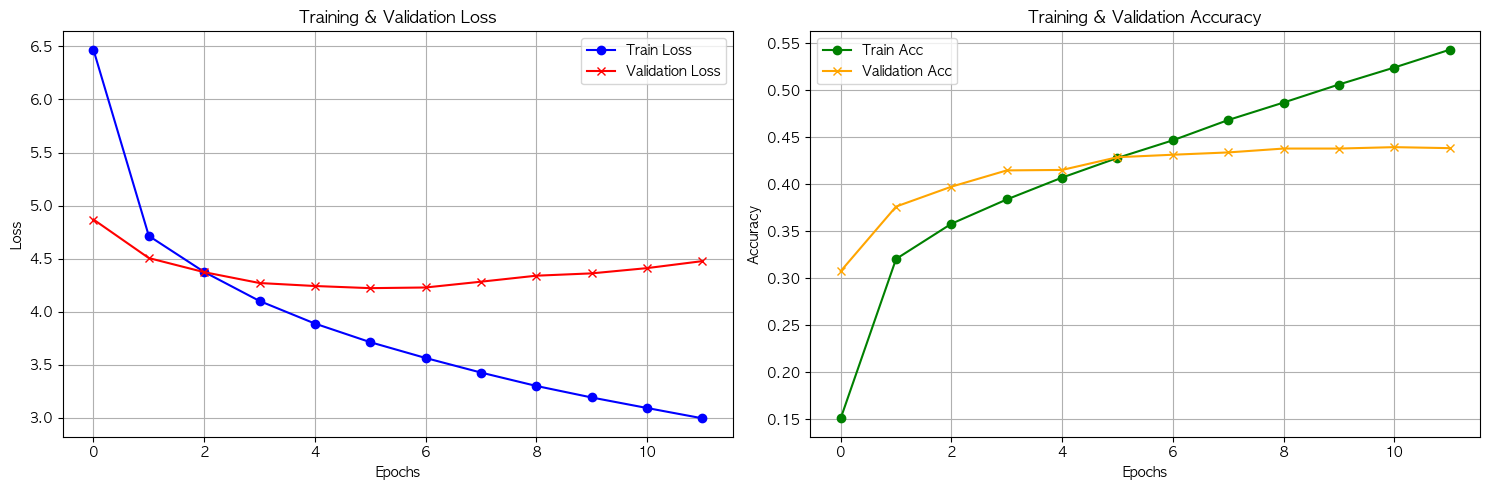

In [540]:
# 1. 시각화 영역 설정 (1행 2열)
plt.figure(figsize=(15, 5))
# --- 좌측: Loss 그래프 ---
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='red', marker='x')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# --- 우측: Accuracy 그래프 ---
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='green', marker='o')
plt.plot(history['val_acc'], label='Validation Acc', color='orange', marker='x')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [541]:
def calculate_bleu(reference, candidate):
    return sentence_bleu([reference], candidate, smoothing_function=SmoothingFunction().method1)

In [542]:
def evaluate(sentence, model, tokenizer, max_len=50):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(sentence)
    # mecab.morphs를 거쳐 spm 인코딩
    tokens = tokenizer.encode_as_ids(" ".join(mecab.morphs(sentence)))
    
    # 앞뒤로 BOS, EOS 처리 (pad_sequences_custom과 동일 논리)
    # spm에서 bos_id=1, eos_id=2임을 가정
    enc_input = torch.tensor([[1] + tokens + [2]], dtype=torch.long).to(CFG["DEVICE"])
    
    # 2. 디코더 입력 초기화 ([BOS]로 시작)
    output = torch.tensor([[1]], dtype=torch.long).to(CFG["DEVICE"])
    
    for i in range(max_len):
        # 마스크 생성
        enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, output)
        
        # 모델 추론
        with torch.no_grad():
            predictions, _, _, _ = model(enc_input, output, enc_mask, dec_enc_mask, dec_mask)
        
        # 마지막 타임스텝의 예측값 가져오기
        predictions = predictions[:, -1:, :]  # [batch, 1, vocab_size]
        predicted_id = torch.argmax(predictions, dim=-1)
        
        # [EOS] 토큰(2)이 나오면 멈춤
        if predicted_id.item() == 2:
            break
            
        # 결과에 추가하여 다음 스텝 입력으로 사용
        output = torch.cat([output, predicted_id], dim=-1)
        
    # 최종 결과 디코딩 (BOS 제외)
    result = tokenizer.decode_ids(output.squeeze().tolist()[1:])
    return result

In [543]:
transformer.eval() 
total_test_loss = 0.0
total_bleu_score = 0.0
sample_cnt = 0
with torch.no_grad():
    for src, tgt in tqdm(test_dataloader, desc="Final Evaluation"):
        # 1. Test Loss 계산 (배치 단위)
        loss, _ = val_step(src, tgt, transformer)

        total_test_loss += loss.item()
        
        # 2. 개별 문장 BLEU 계산 및 샘플 출력
        for i in range(len(src)):
            # 정답 토큰 및 문자열 복원
            reference_tokens = [tokenizer.id_to_piece(int(t)) for t in tgt[i] if t > 2]
            reference_str = tokenizer.decode_pieces(reference_tokens)
            
            # 질문 복원 및 모델 답변 생성
            input_sentence = tokenizer.decode_ids(src[i].tolist())
            candidate_str = evaluate(input_sentence, transformer, tokenizer)
             # ✅ 정답지처럼 똑같이 SentencePiece 토큰으로 쪼개서 비교 (공평)
            candidate_tokens = [tokenizer.id_to_piece(t) for t in tokenizer.encode_as_ids(candidate_str)]
            
            # 개별 스코어 계산
            current_bleu = calculate_bleu(reference_tokens, candidate_tokens)
            total_bleu_score += current_bleu
            
            # 📌 상위 5개 샘플만 시각적으로 출력
            if sample_cnt < 5:
                print(f"\n[Sample {sample_cnt + 1}]")
                print(f"Q (질문) : {input_sentence}")
                print(f"A (정답) : {reference_str}")
                print(f"P (예측) : {candidate_str}")
                print(f"BLEU     : {current_bleu:.4f}")
                print("-" * 50)
                
            sample_cnt += 1
# 최종 평균 산출
avg_test_loss = total_test_loss / len(test_dataloader)
avg_bleu_score = total_bleu_score / sample_cnt
print(f"\n📢 [Node 12 Report] Final Model Performance")
print(f"   - Final Train Loss: {avg_train_loss:.4f}")
print(f"   - Final Val Loss  : {avg_val_loss:.4f}")
print(f"   - Final Test Loss : {avg_test_loss:.4f}") 
print(f"   - Final BLEU Score: {avg_bleu_score:.4f} ✨")

Final Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]


[Sample 1]
Q (질문) : 오락가락 하 네
A (정답) : 이별 이 변덕 스럽 게 만들 곤 하 지요 .
P (예측) : 사랑 했 던 만큼 쉬운 일 이 아니 라는 걸 잊 으세요 .
BLEU     : 0.0137
--------------------------------------------------

[Sample 2]
Q (질문) : 통화 를 하 긴 했 는데 . 힘드 네
A (정답) : 연락 하 면서 감정 들 이 다시 생각나 니까요 .
P (예측) : 그동안 힘들 겠 지만 잘 버텨낼 수 있 어요 .
BLEU     : 0.0123
--------------------------------------------------

[Sample 3]
Q (질문) : 커플 여행 어떻게 생각 해 ?
A (정답) : 누구 랑 가 느냐 가 중요 하 겠 죠 .
P (예측) : 연애 초기 가 필요 한 거 같 아요 .
BLEU     : 0.0203
--------------------------------------------------

[Sample 4]
Q (질문) : 만난 지 얼마 안 됐 는데 결혼 해도 될까 ?
A (정답) : 오래 만나 고 알 면 좋 겠 지만 살 면서 알아봐 도 괜찮 아요 .
P (예측) : 사람 마다 다르 면 사귀 면 돼요 .
BLEU     : 0.0137
--------------------------------------------------

[Sample 5]
Q (질문) : 남친 이랑 대화 가 잘 돼서 좋 아
A (정답) : 말 통하 는 게 중요 하 죠 .
P (예측) : 사귀 면 더 잘 하 는 게 좋 겠 어요 .
BLEU     : 0.0359
--------------------------------------------------


Final Evaluation:  14%|█▍        | 1/7 [00:15<01:34, 15.79s/it]


KeyboardInterrupt: 

In [ ]:
# --- [ 최종 제출 양식 출력 셀 ] ---
# 1. 테스트 예문 정의
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]
print("# 예문")
for i, s in enumerate(test_sentences):
    print(f"{i+1}. {s}")
print("\n---\n")
print("# 제출\n")
# 2. Translations (실제 추론 결과)
print("Translations")
for i, sentence in enumerate(test_sentences):
    # 위에서 정의한 evaluate 함수 사용
    answer = evaluate(sentence, transformer, tokenizer)
    print(f"> {i+1}. {answer} <end>")
# 3. Hyperparameters (모델 객체에서 실제 값 추출)
print("\nHyperparameters")
# 모델 내부의 실제 구조 정보를 읽어옵니다.
print(f"> n_layers: {transformer.encoder.n_layers}")
print(f"> d_model: {int(transformer.d_model)}")
print(f"> n_heads: {transformer.encoder.enc_layers[0].enc_self_attn.num_heads}")
print(f"> d_ff: {transformer.encoder.enc_layers[0].ffn.fc1.out_features}")
print(f"> dropout: {transformer.do.p}")
# 4. Training Parameters (설정 변수에서 실제 값 추출)
print("\nTraining Parameters")
print(f"> Warmup Steps: {learning_rate.warmup_steps}")
print(f"> Batch Size: {CFG['BATCH_SIZE']}")
print(f"> Epoch At: {CFG['EPOCHS']}")

# 예문
1. 지루하다, 놀러가고 싶어.
2. 오늘 일찍 일어났더니 피곤하다.
3. 간만에 여자친구랑 데이트 하기로 했어.
4. 집에 있는다는 소리야.

---

# 제출

Translations
> 1. 여행 은 항상 좋 죠 . <end>
> 2. 잘못 주무세요 . <end>
> 3. 즐거운 데이트 가 되 겠 네요 . <end>
> 4. 집착 하 지 마세요 . <end>

Hyperparameters
> n_layers: 2
> d_model: 512
> n_heads: 8
> d_ff: 1024
> dropout: 0.5

Training Parameters
> Warmup Steps: 600
> Batch Size: 64
> Epoch At: 12


In [ ]:
def visualize_attention(src, tar, attention_map, n_heads=8):
    # 8개 헤드 + 1개 합산(Sum) = 총 9개의 그래프를 3x3 격자로 그립니다.
    fig = plt.figure(figsize=(15, 15))
    
    # SentencePiece의 특수 공백 기호(U+2581)를 언더바(_)로 치환하여 폰트 깨짐 방지
    src_labels = [s.replace('\u2581', '_') for s in src]
    tar_labels = [t.replace('\u2581', '_') for t in tar]
    
    for i in range(n_heads + 1):
        ax = fig.add_subplot(3, 3, i+1)
        
        if i < n_heads:
            # 1~8번: 개별 헤드 시각화
            attn = attention_map[i].cpu().detach().numpy()
            ax.set_title(f'Head {i+1}', fontsize=10)
        else:
            # 9번: 모든 헤드를 더한(Sum) 통합 맵 시각화
            # [head, tar, src] -> [tar, src]
            attn = attention_map.sum(dim=0).cpu().detach().numpy()
            ax.set_title('Total Summed Attention', fontsize=12, fontweight='bold', color='red')
            
        # 히트맵 출력
        ax.matshow(attn, cmap='viridis')

        # 📌 경고 방지 및 좌표 설정
        ax.set_xticks(range(len(src_labels)))
        ax.set_yticks(range(len(tar_labels)))

       
        ax.set_xticklabels(src_labels, rotation=90)
        ax.set_yticklabels(tar_labels)
       

    plt.tight_layout()
    plt.show()


In [ ]:
def get_attention(sentence, model, tokenizer):
    model.eval()
    
    sentence = preprocess_sentence(sentence)
    processed_tokens = mecab.morphs(sentence)
    
    # 📌 이미 <s> ... </s> 가 포함되어 나옵니다.
    tokens = tokenizer.encode_as_ids(" ".join(processed_tokens))
    
    # 📌 [수정] 수동으로 [1], [2]를 더하지 않고 토크나이저 결과만 그대로 사용합니다.
    enc_input = torch.tensor([tokens], dtype=torch.long).to(CFG["DEVICE"])
    
    # 디코더 시작 토큰 (BOS=1)
    output = torch.tensor([[1]], dtype=torch.long).to(CFG["DEVICE"])
    
    # 문장 생성 루프
    for i in range(20):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, output)
        with torch.no_grad():
            predictions, _, _, _ = model(enc_input, output, enc_mask, dec_enc_mask, dec_mask)
        
        predicted_id = torch.argmax(predictions[:, -1:, :], dim=-1)
        output = torch.cat([output, predicted_id], dim=-1)
        
        if predicted_id.item() == 2: break 
    
    # 최종 어텐션 추출 (위에서 완성된 output 사용)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, output)
    with torch.no_grad():
        _, _, _, final_dec_enc_attns = model(enc_input, output, enc_mask, dec_enc_mask, dec_mask)

    attention_map = final_dec_enc_attns[-1][0] 
    
    # 라벨 역시 텐서에 들어있는 그대로만 가져옵니다.
    src_tokens = [tokenizer.id_to_piece(int(t)) for t in enc_input[0].tolist()]
    tar_tokens = [tokenizer.id_to_piece(int(t)) for t in output[0].tolist()]
    
    print(f"질문: {sentence}")
    print(f"답변: {tokenizer.decode_ids(output[0].tolist()[1:])}")
    
    visualize_attention(src_tokens, tar_tokens, attention_map)


🎯 시작: 제출용 예문 4종 어텐션 맵 추출


[예문 1] 시각화 중...
질문: 지루하다, 놀러가고 싶어.
답변: 여행 은 항상 좋 죠 .


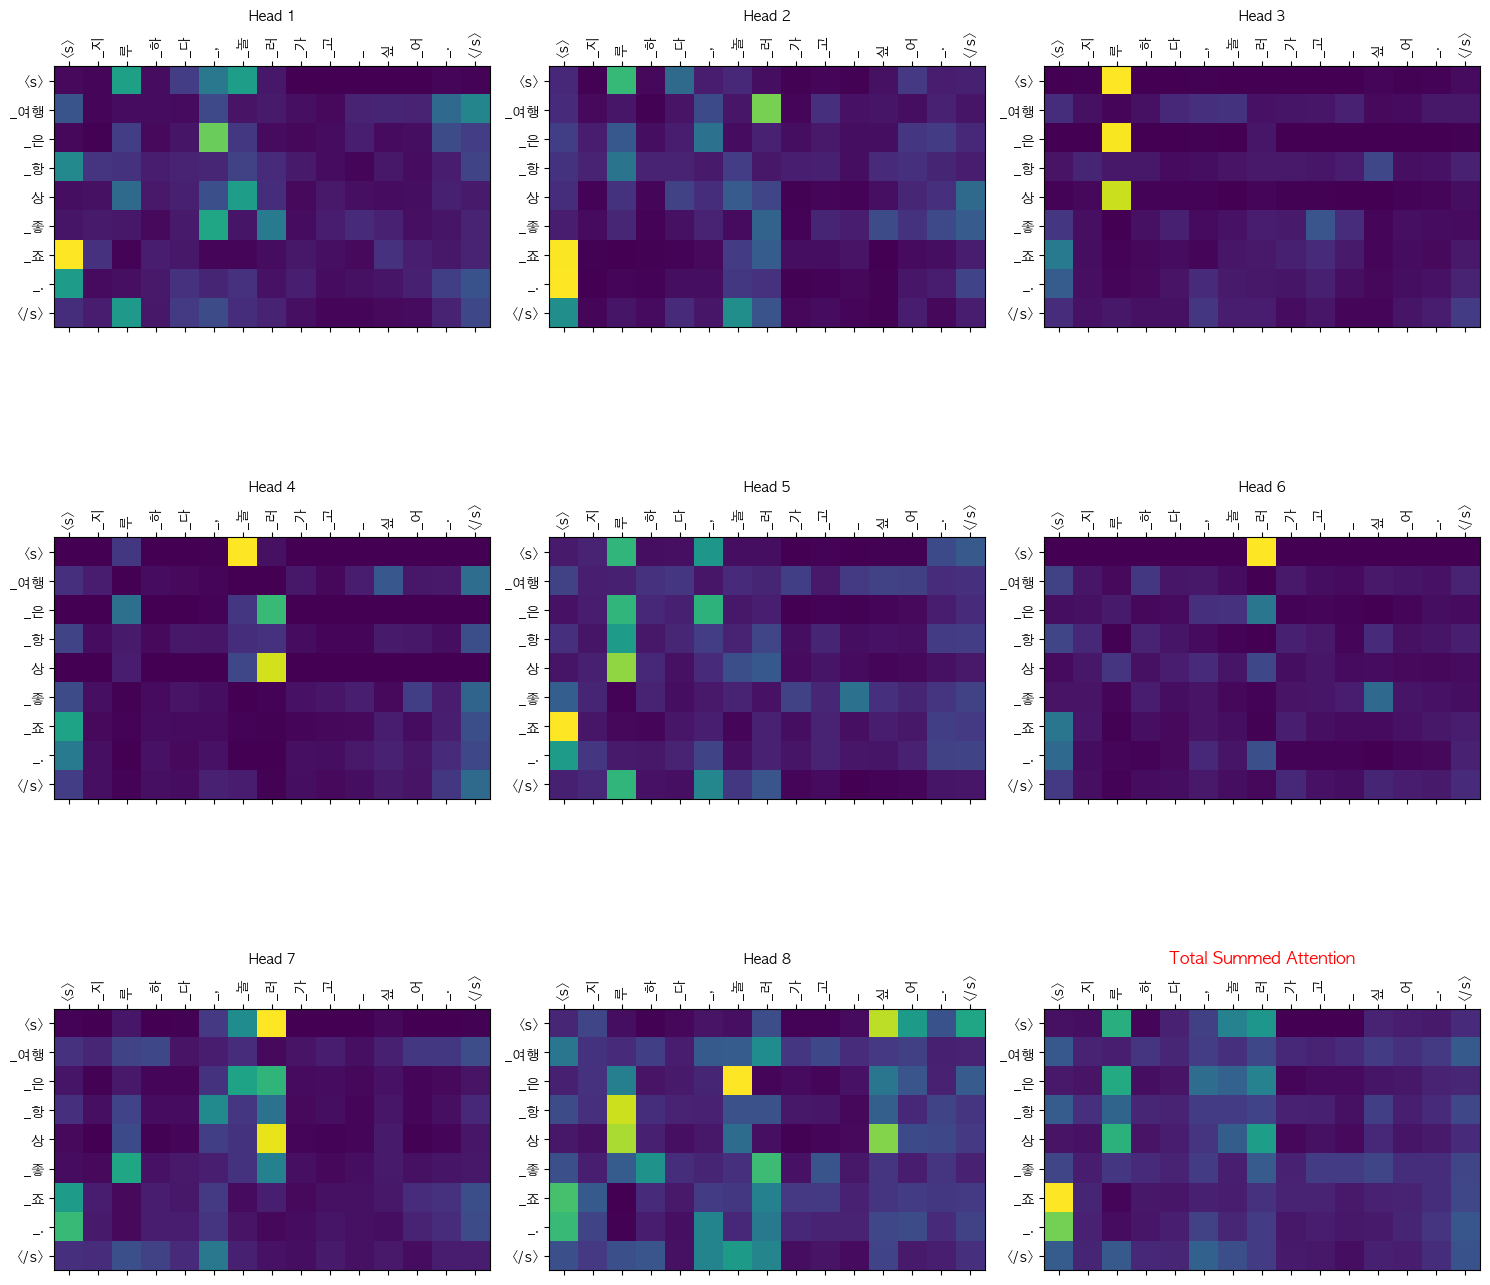


[예문 2] 시각화 중...
질문: 오늘 일찍 일어났더니 피곤하다.
답변: 오늘 은 주무세요 .


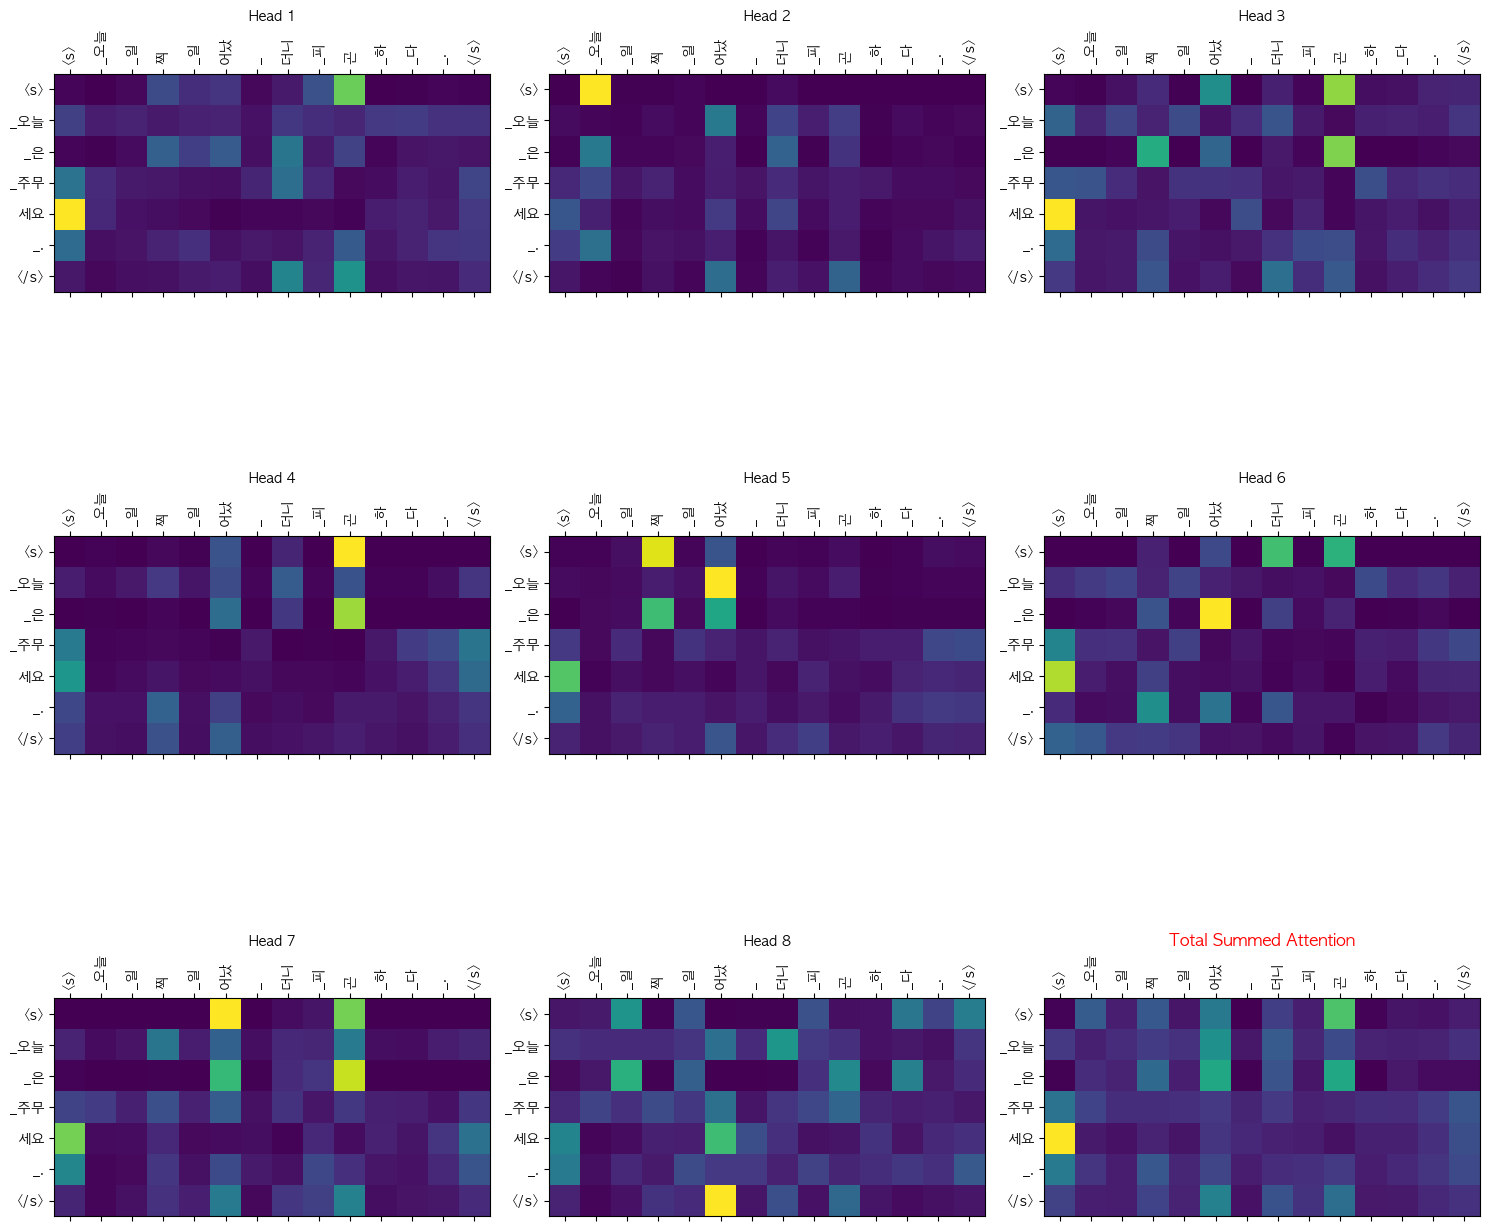


[예문 3] 시각화 중...
질문: 간만에 여자친구랑 데이트 하기로 했어.
답변: 즐거운 데이트 가 되 겠 네요 .


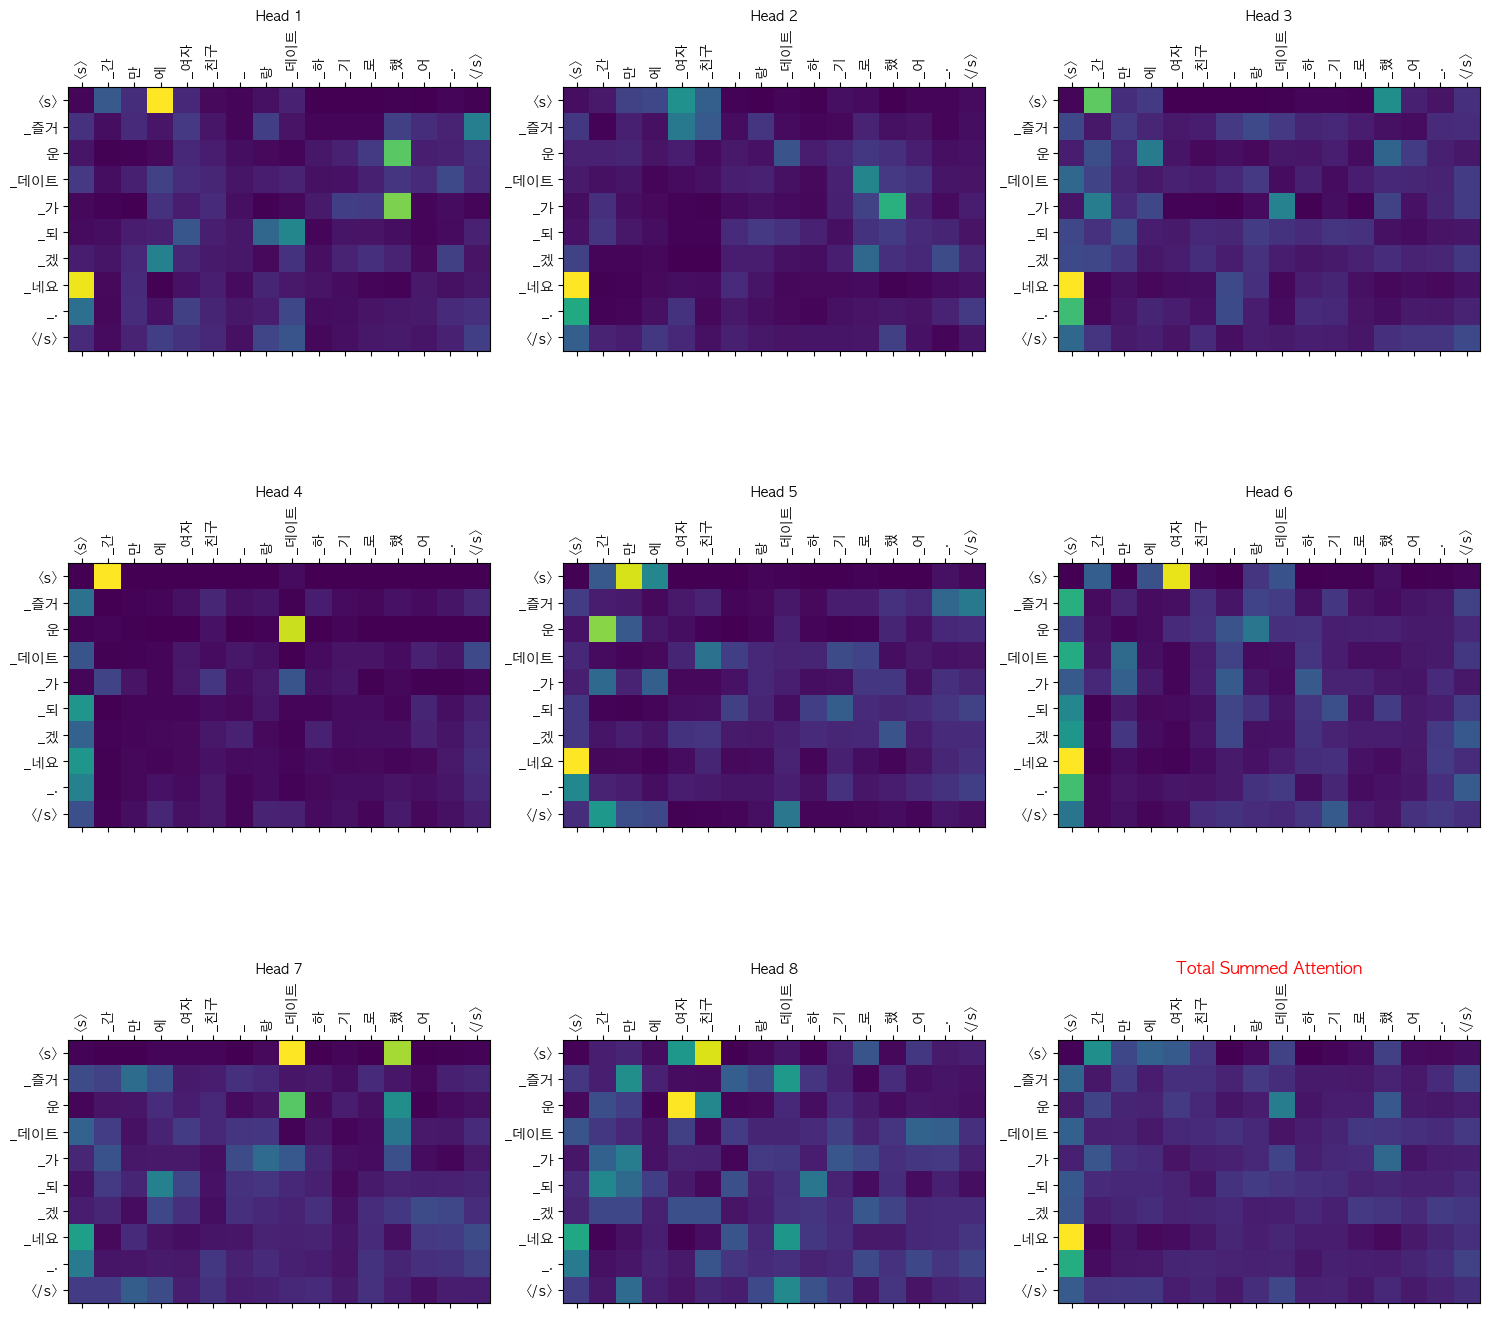


[예문 4] 시각화 중...
질문: 집에 있는다는 소리야.
답변: 세상 에 는 흥미 를 가져 보 세요 .


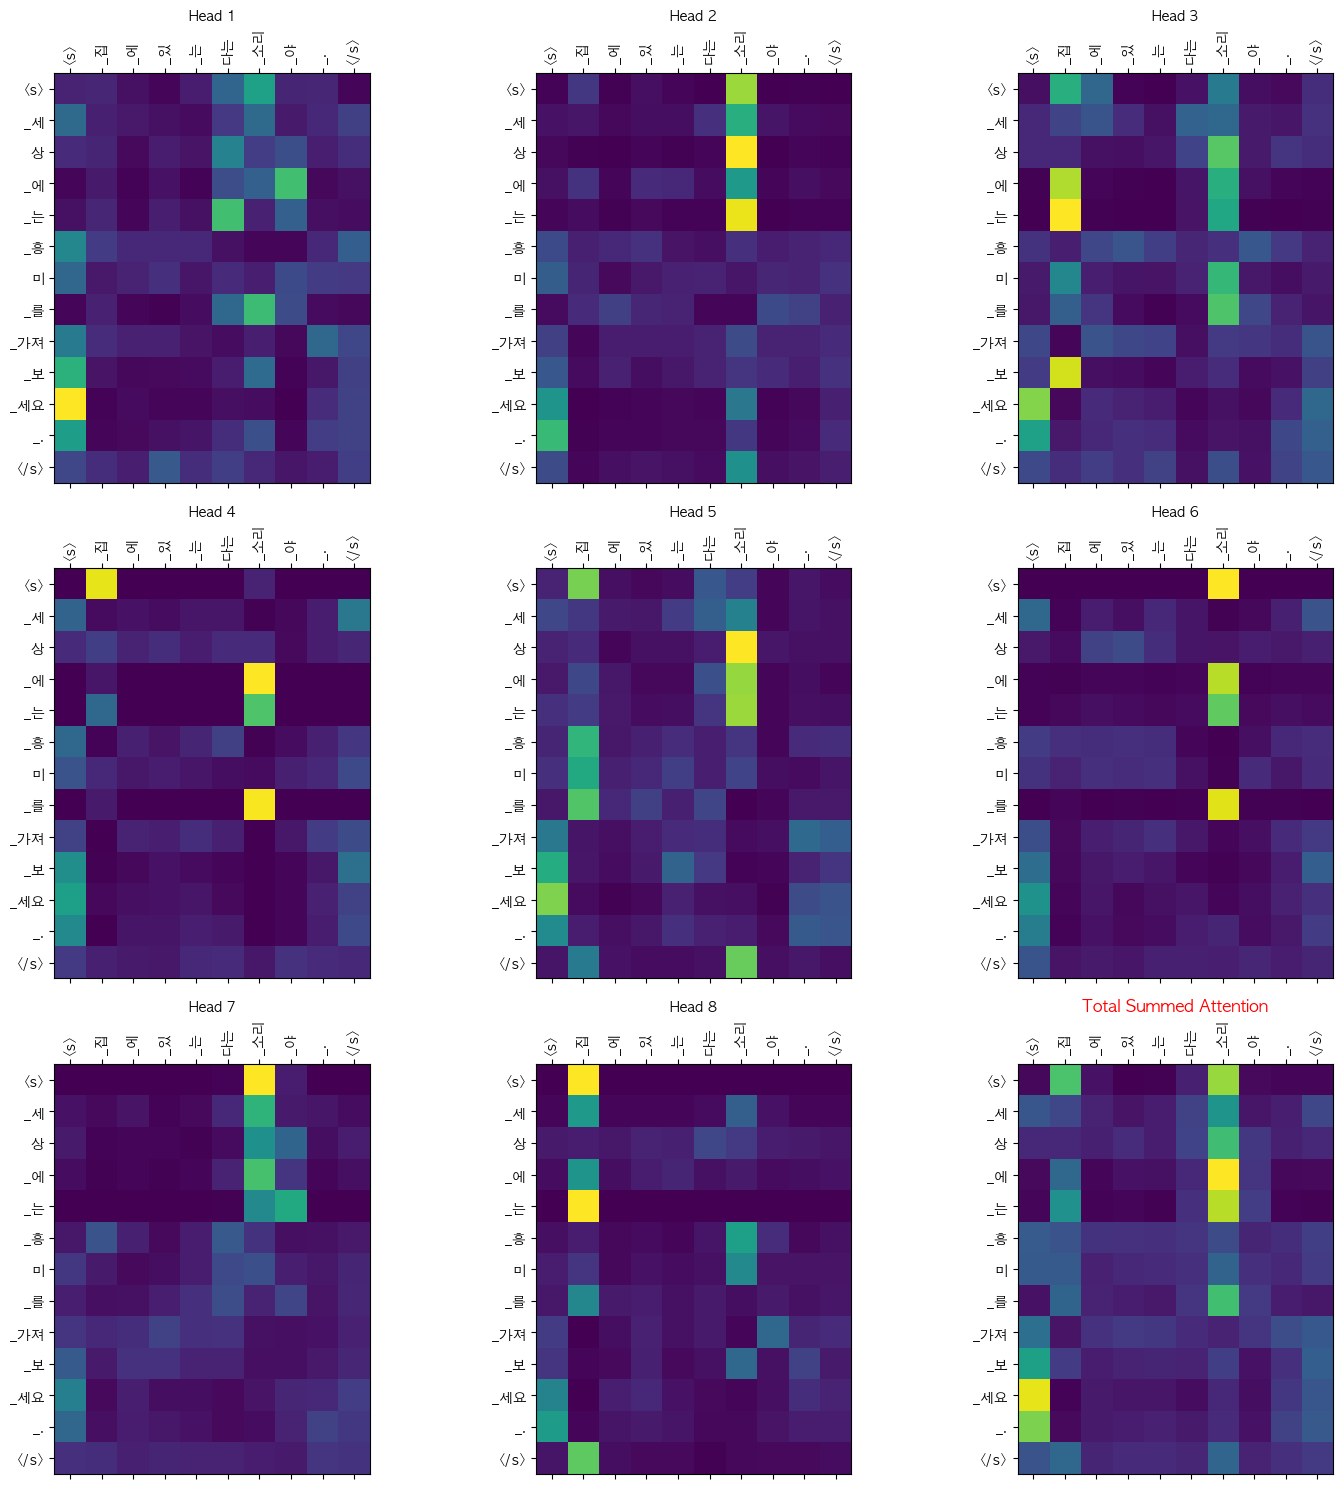


✅ 모든 시각화가 완료되었습니다.


In [ ]:
print("🎯 시작: 제출용 예문 4종 어텐션 맵 추출\n")
for i, sentence in enumerate(test_sentences):
    print(f"\n[예문 {i+1}] 시각화 중...")
    
    # 이전에 정의한 get_attention 함수 호출
    # 만약 한글 깨짐이 걱정된다면 함수 내에서 폰트 설정을 체크하세요.
    try:
        get_attention(sentence, transformer, tokenizer)
    except Exception as e:
        print(f"오류 발생 ({sentence}): {e}")
        
print("\n✅ 모든 시각화가 완료되었습니다.")

In [ ]:
import itertools
import copy
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
import math

if CFG.get('GRID_SEARCH', False):
    # 1. 탐색할 하이퍼파라미터 그리드 (좀 더 촘촘하게 확장!)
    param_grid = {
        'DROPOUT': [0.3, 0.4, 0.5],          # 3가지
        'WEIGHT_DECAY': [1e-4, 1e-3],        # 2가지
        'LABEL_SMOOTHING': [0.0, 0.1],       # 2가지
        'WARMUP_STEPS': [600, 1000],         # 2가지
        'BATCH_SIZE': [32, 64],              # 2가지
        'D_FF': [1024, 2048]                 # 2가지
    }

    keys = param_grid.keys()
    combinations = list(itertools.product(*param_grid.values()))

    best_val_loss = float('inf')
    best_params = {}

    print(f"🚀 총 {len(combinations)}개의 조합으로 Grid Search를 시작합니다!\n")

    for idx, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f"==================================================")
        print(f"🧪 [실험 {idx+1}/{len(combinations)}] 현재 파라미터:")
        print(f"   {params}")
        
        # ⭐ 모델 새로 선언
        current_transformer = Transformer(
            n_layers=CFG['N_LAYER'],
            d_model=CFG['D_MODEL'],
            n_heads=8,
            d_ff=params['D_FF'], # 📌 파라미터에서 D_FF 적용
            src_vocab_size=CFG["VOCAB_SIZE"],
            tgt_vocab_size=CFG["VOCAB_SIZE"],
            pos_len=CFG["PRE_MAX_LEN"],
            dropout=params['DROPOUT'],
            shared_fc=True,
            shared_emb=True
        ).to(CFG["DEVICE"])
        
        # 📌 필수: 가중치 초기화 적용 (이게 없으면 로스가 폭발할 수 있음!)
        current_transformer.apply(init_weights)
    
        current_lr_scheduler = LearningRateScheduler(CFG['D_MODEL'], warmup_steps=params['WARMUP_STEPS'])
    
        # 📌 필수: 원본 논문 세팅(betas=(0.9, 0.98), eps=1e-9)과 동일하게 적용
        current_optimizer = torch.optim.AdamW(
            current_transformer.parameters(), 
            lr=current_lr_scheduler(1),
            betas=(0.9, 0.98),
            eps=1e-9,
            weight_decay=params['WEIGHT_DECAY']
        )
        
        # ⭐ 배치 사이즈 다이나믹 세팅
        current_train_dataloader = DataLoader(train_dataset, batch_size=params['BATCH_SIZE'], shuffle=True)
        current_val_dataloader = DataLoader(val_dataset, batch_size=params['BATCH_SIZE'], shuffle=False)

        global_step = 1
        search_epochs = 12
        
        best_loss_in_this_combo = float('inf')
        best_epoch_in_this_combo = -1
        stop_early = False
    
        for epoch in range(search_epochs):
            if stop_early: break
            
            # [ TRAIN ]
            current_transformer.train()
            total_train_loss = 0.0
            
            for batch, (src, tgt) in enumerate(current_train_dataloader):
                lr = current_lr_scheduler(global_step)
                for param_group in current_optimizer.param_groups:
                    param_group['lr'] = lr
                
                loss, acc = train_step(src, tgt, current_transformer, current_optimizer, label_smoothing=params['LABEL_SMOOTHING'])
                
                # 📌 로스 폭발(NaN 또는 너무 큰 값) 방지 방어 코드
                if math.isnan(loss.item()) or loss.item() > 100:
                    print(f"🚨 로스 폭발 감지 (Loss: {loss.item():.2f}). 해당 파라미터 조합 실험을 즉각 중단합니다.")
                    stop_early = True
                    break
                    
                global_step += 1
                total_train_loss += loss.item()
                
            if stop_early: continue
            
            # [ VALIDATION ]
            current_transformer.eval()
            total_val_loss = 0.0
            with torch.no_grad():
                for batch, (src, tgt) in enumerate(current_val_dataloader):
                    v_loss, v_acc = val_step(src, tgt, current_transformer, label_smoothing=params['LABEL_SMOOTHING'])
                    total_val_loss += v_loss.item()
                
            current_val_loss = total_val_loss / len(current_val_dataloader)
            
            if current_val_loss < best_loss_in_this_combo:
                best_loss_in_this_combo = current_val_loss
                best_epoch_in_this_combo = epoch + 1
    
        if not stop_early:
            print(f"👉 실험 {idx+1} 최고 성적 Val Loss: {best_loss_in_this_combo:.4f} (달성 에포크: {best_epoch_in_this_combo} / {search_epochs})")
        else:
            best_loss_in_this_combo = float('inf')  # 폭발한 건 꼴등 처리
    
        # 4. 전체 최고 기록 갱신
        if best_loss_in_this_combo < best_val_loss:
            print(f"🎉 갱신! 전체 1등 모델을 찾았습니다! (Val Loss: {best_loss_in_this_combo:.4f} @ Epoch {best_epoch_in_this_combo})")
            best_val_loss = best_loss_in_this_combo
            best_params = params
            best_params['BEST_EPOCH'] = best_epoch_in_this_combo

    print(f"\n==================================================")
    print(f"🏆 Grid Search 완료!")
    if best_val_loss != float('inf'):
        print(f"   - 전체 1등 모델 최고 성능 Val Loss: {best_val_loss:.4f}")
        print(f"   - 1등 파라미터 조합: {best_params}")
    else:
        print("   - 모든 실험이 실패했습니다. (로스 폭발)")

else:
    print('⏭️ CFG["GRID_SEARCH"]가 False로 설정되어 있어 Grid Search를 건너뜁니다.')


🚀 총 36개의 조합으로 Grid Search를 시작합니다!

🧪 [실험 1/36] 현재 파라미터: {'DROPOUT': 0.2, 'WEIGHT_DECAY': 1e-05, 'LABEL_SMOOTHING': 0.0, 'WARMUP_STEPS': 600}


KeyboardInterrupt: 